# Lead Conversion Prediction Engine

## Exploratory Data Analysis

This notebook performs exploratory data analysis on the validated
synthetic lead dataset before model development.

The analysis covers:

- Dataset structure and data types
- Missing values
- Target distribution
- Categorical feature distributions
- Numerical feature distributions
- Relationships between features and conversion
- Correlations
- Potential outliers

Model-training preprocessing is intentionally not performed during EDA.
Imputation, encoding, and scaling will later be performed inside a
leakage-safe scikit-learn pipeline after the train/test split.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Project root
BASE_DIR = Path.cwd()

# If Jupyter starts inside the notebooks folder,
# move one level up to the project root.
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_FILE = BASE_DIR / "data" / "processed" / "leads_validated.csv"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plotting style
sns.set_theme(style="whitegrid")

print(f"Dataset: {DATA_FILE}")
print(f"Figures: {FIGURES_DIR}")

Dataset: e:\lead-conversion-prediction\data\processed\leads_validated.csv
Figures: e:\lead-conversion-prediction\reports\figures


In [2]:
df = pd.read_csv(DATA_FILE)

print(f"Shape: {df.shape}")

display(df.head())

Shape: (6000, 16)


,lead_id,lead_source,industry,location,company_size,lead_age_days,interactions,followups,response_time_hours,quotation_sent,quotation_value,website_visits,previous_customer,demo_attended,salesperson_experience,converted
0,100001,Cold Call,Healthcare,Pune,Medium,45.0,4,0,31.50,0,0.0,7,0,1,10,1
1,100002,Email Campaign,Technology,Mumbai,Small,44.0,6,3,31.56,0,0.0,6,0,0,3,1
2,100003,Cold Call,Retail,Delhi,Medium,119.0,6,0,33.46,0,0.0,4,0,1,2,0
3,100004,Social Media,Technology,Hyderabad,Large,88.0,5,1,21.33,0,0.0,2,0,1,11,0
4,100005,Website,Technology,Pune,Medium,104.0,6,3,15.10,0,0.0,4,0,0,5,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   lead_id                 6000 non-null   int64  
 1   lead_source             5940 non-null   str    
 2   industry                5940 non-null   str    
 3   location                6000 non-null   str    
 4   company_size            5940 non-null   str    
 5   lead_age_days           5990 non-null   float64
 6   interactions            6000 non-null   int64  
 7   followups               6000 non-null   int64  
 8   response_time_hours     5930 non-null   float64
 9   quotation_sent          6000 non-null   int64  
 10  quotation_value         5940 non-null   float64
 11  website_visits          6000 non-null   int64  
 12  previous_customer       6000 non-null   int64  
 13  demo_attended           6000 non-null   int64  
 14  salesperson_experience  6000 non-null   int64  
 15

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
lead_id,6000.0,NaN,NaN,NaN,103000.5,1732.195139,100001.0,101500.75,103000.5,104500.25,106000.0
lead_source,5940,6,Website,1533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,5940,6,Technology,1424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,6000,7,Pune,893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,5940,4,Medium,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_age_days,5990.0,NaN,NaN,NaN,60.251085,34.505491,1.0,31.0,60.0,90.0,120.0
interactions,6000.0,NaN,NaN,NaN,5.0065,2.270459,0.0,3.0,5.0,6.0,15.0
followups,6000.0,NaN,NaN,NaN,2.016833,1.43651,0.0,1.0,2.0,3.0,9.0
response_time_hours,5930.0,NaN,NaN,NaN,22.971192,18.684009,1.62,11.01,17.845,28.6375,168.0
quotation_sent,6000.0,NaN,NaN,NaN,0.414333,0.492648,0.0,0.0,0.0,1.0,1.0


In [5]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percentage
response_time_hours,70,1.17
lead_source,60,1.00
industry,60,1.00
company_size,60,1.00
quotation_value,60,1.00
lead_age_days,10,0.17


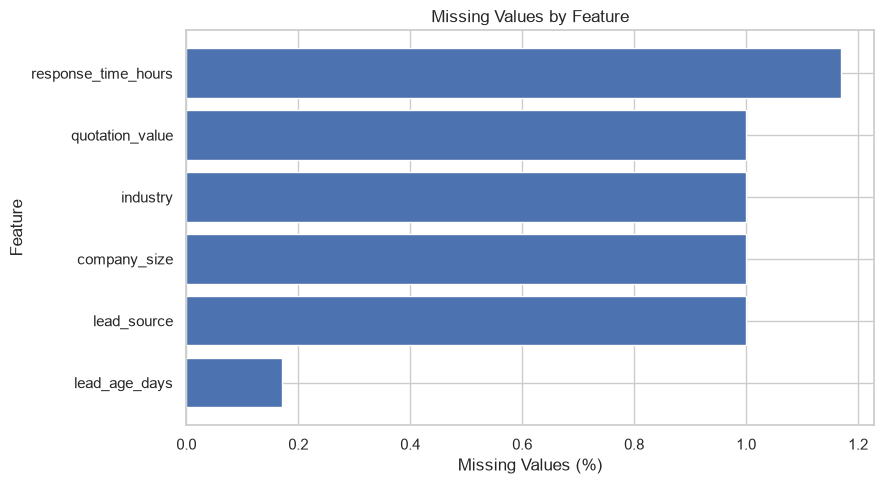

Saved figure: e:\lead-conversion-prediction\reports\figures\missing_values.png


In [6]:
plt.figure(figsize=(9, 5))

missing_plot = missing_summary.sort_values(
    "missing_percentage",
    ascending=True
)

plt.barh(
    missing_plot.index,
    missing_plot["missing_percentage"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")

plt.tight_layout()

missing_figure = FIGURES_DIR / "missing_values.png"
plt.savefig(missing_figure, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {missing_figure}")

In [7]:
target_counts = df["converted"].value_counts().sort_index()
target_percent = (
    df["converted"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent
})

display(target_summary)

,count,percentage
converted,,
0,3390,56.5
1,2610,43.5


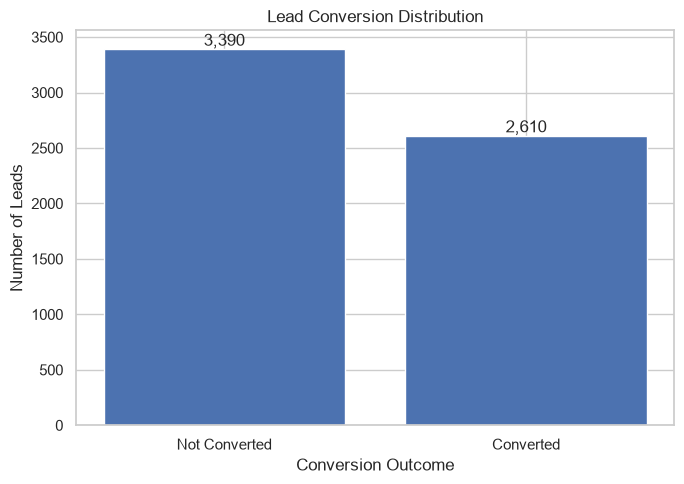

Saved figure: e:\lead-conversion-prediction\reports\figures\target_distribution.png


In [8]:
plt.figure(figsize=(7, 5))

labels = ["Not Converted", "Converted"]
values = target_counts.values

bars = plt.bar(labels, values)

plt.ylabel("Number of Leads")
plt.xlabel("Conversion Outcome")
plt.title("Lead Conversion Distribution")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

target_figure = FIGURES_DIR / "target_distribution.png"
plt.savefig(target_figure, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {target_figure}")

LEAD_SOURCE DISTRIBUTION


,count
lead_source,
Website,1533
Referral,1050
Cold Call,956
Email Campaign,903
Social Media,818
Partner,680
NaN,60


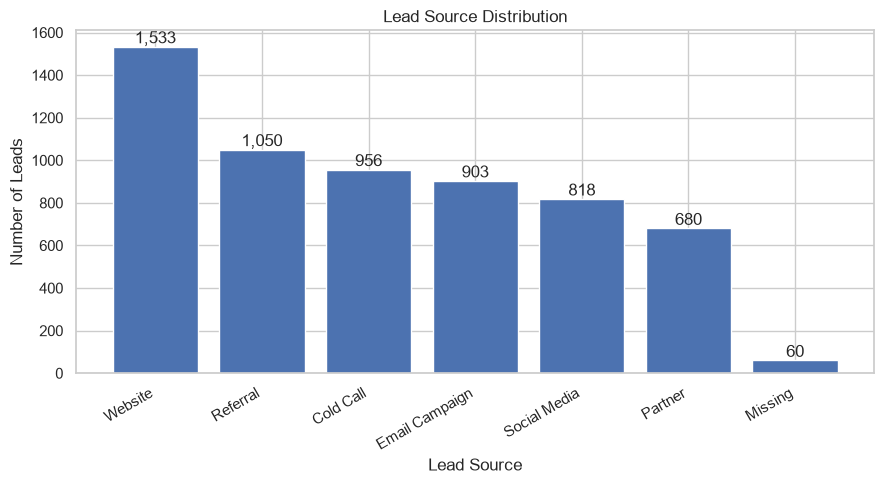

Saved figure: e:\lead-conversion-prediction\reports\figures\lead_source_distribution.png
INDUSTRY DISTRIBUTION


,count
industry,
Technology,1424
Retail,1078
Finance,1000
Healthcare,878
Manufacturing,865
Education,695
NaN,60


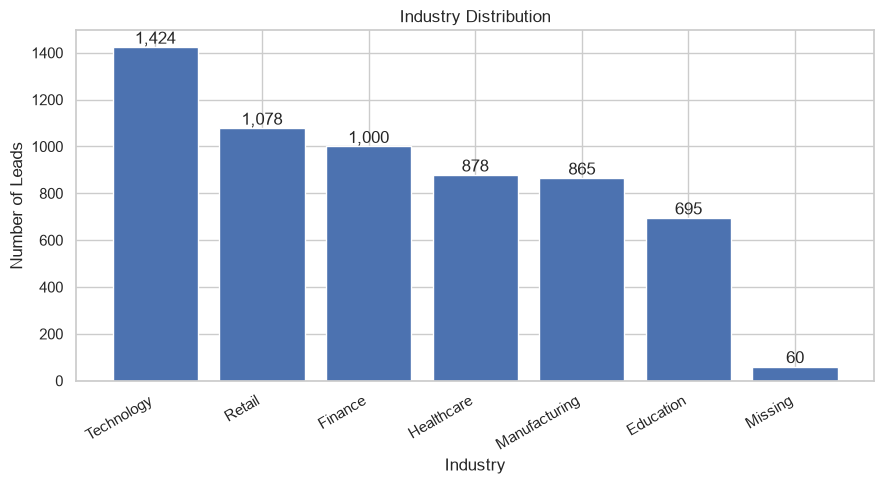

Saved figure: e:\lead-conversion-prediction\reports\figures\industry_distribution.png
LOCATION DISTRIBUTION


,count
location,
Pune,893
Bengaluru,875
Delhi,872
Hyderabad,870
Mumbai,836
Chennai,828
Kolkata,826


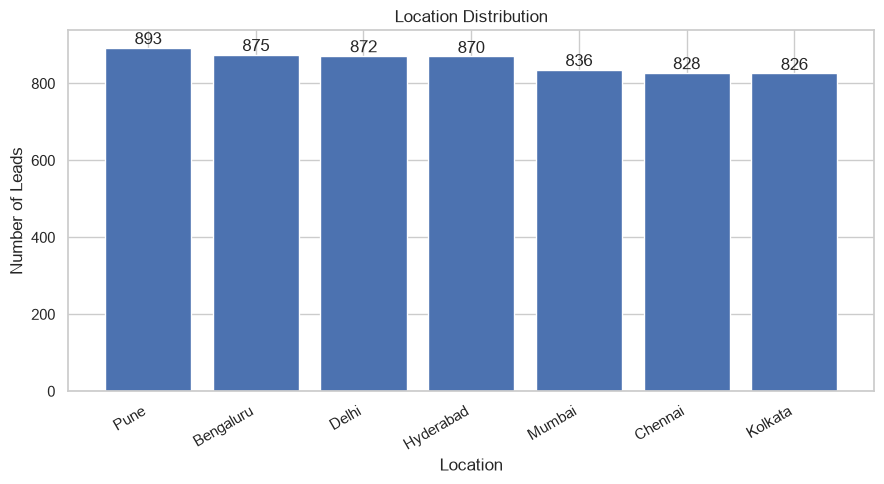

Saved figure: e:\lead-conversion-prediction\reports\figures\location_distribution.png
COMPANY_SIZE DISTRIBUTION


,count
company_size,
Medium,2030
Small,1761
Large,1515
Enterprise,634
NaN,60


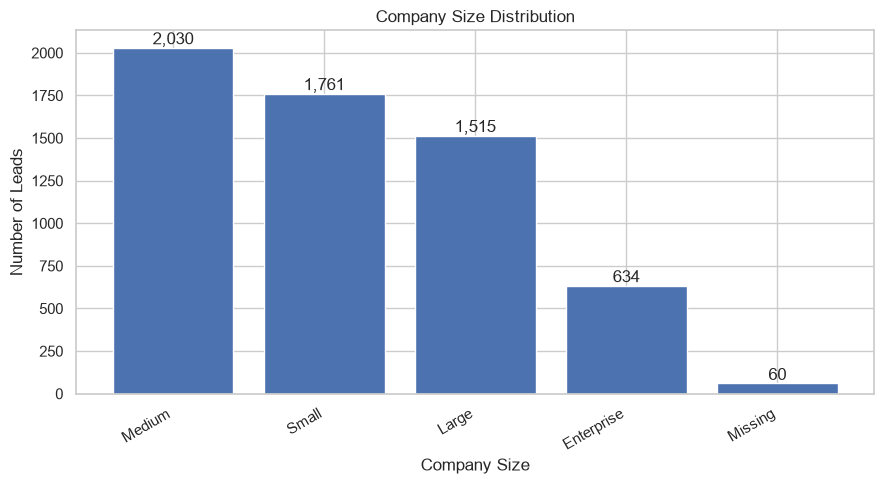

Saved figure: e:\lead-conversion-prediction\reports\figures\company_size_distribution.png


In [10]:
categorical_features = [
    "lead_source",
    "industry",
    "location",
    "company_size"
]

for feature in categorical_features:
    print("=" * 70)
    print(f"{feature.upper()} DISTRIBUTION")
    print("=" * 70)

    display(
        df[feature]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )

    plt.figure(figsize=(9, 5))

    counts = df[feature].fillna("Missing").value_counts()

    bars = plt.bar(
        counts.index.astype(str),
        counts.values
    )

    plt.title(f"{feature.replace('_', ' ').title()} Distribution")
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Number of Leads")
    plt.xticks(rotation=30, ha="right")

    for bar, value in zip(bars, counts.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    figure_path = FIGURES_DIR / f"{feature}_distribution.png"
    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved figure: {figure_path}")

In [11]:
numerical_features = [
    "lead_age_days",
    "interactions",
    "followups",
    "response_time_hours",
    "quotation_value",
    "website_visits",
    "salesperson_experience"
]

display(df[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
lead_age_days,5990.0,60.251085,34.505491,1.00,31.00,60.000,90.0000,120.0
interactions,6000.0,5.006500,2.270459,0.00,3.00,5.000,6.0000,15.0
followups,6000.0,2.016833,1.436510,0.00,1.00,2.000,3.0000,9.0
response_time_hours,5930.0,22.971192,18.684009,1.62,11.01,17.845,28.6375,168.0
quotation_value,5940.0,42617.415689,79630.505054,0.00,0.00,0.000,60297.9675,1000000.0
website_visits,6000.0,4.021333,1.966348,0.00,3.00,4.000,5.0000,12.0
salesperson_experience,6000.0,8.014833,4.321812,1.00,4.00,8.000,12.0000,15.0


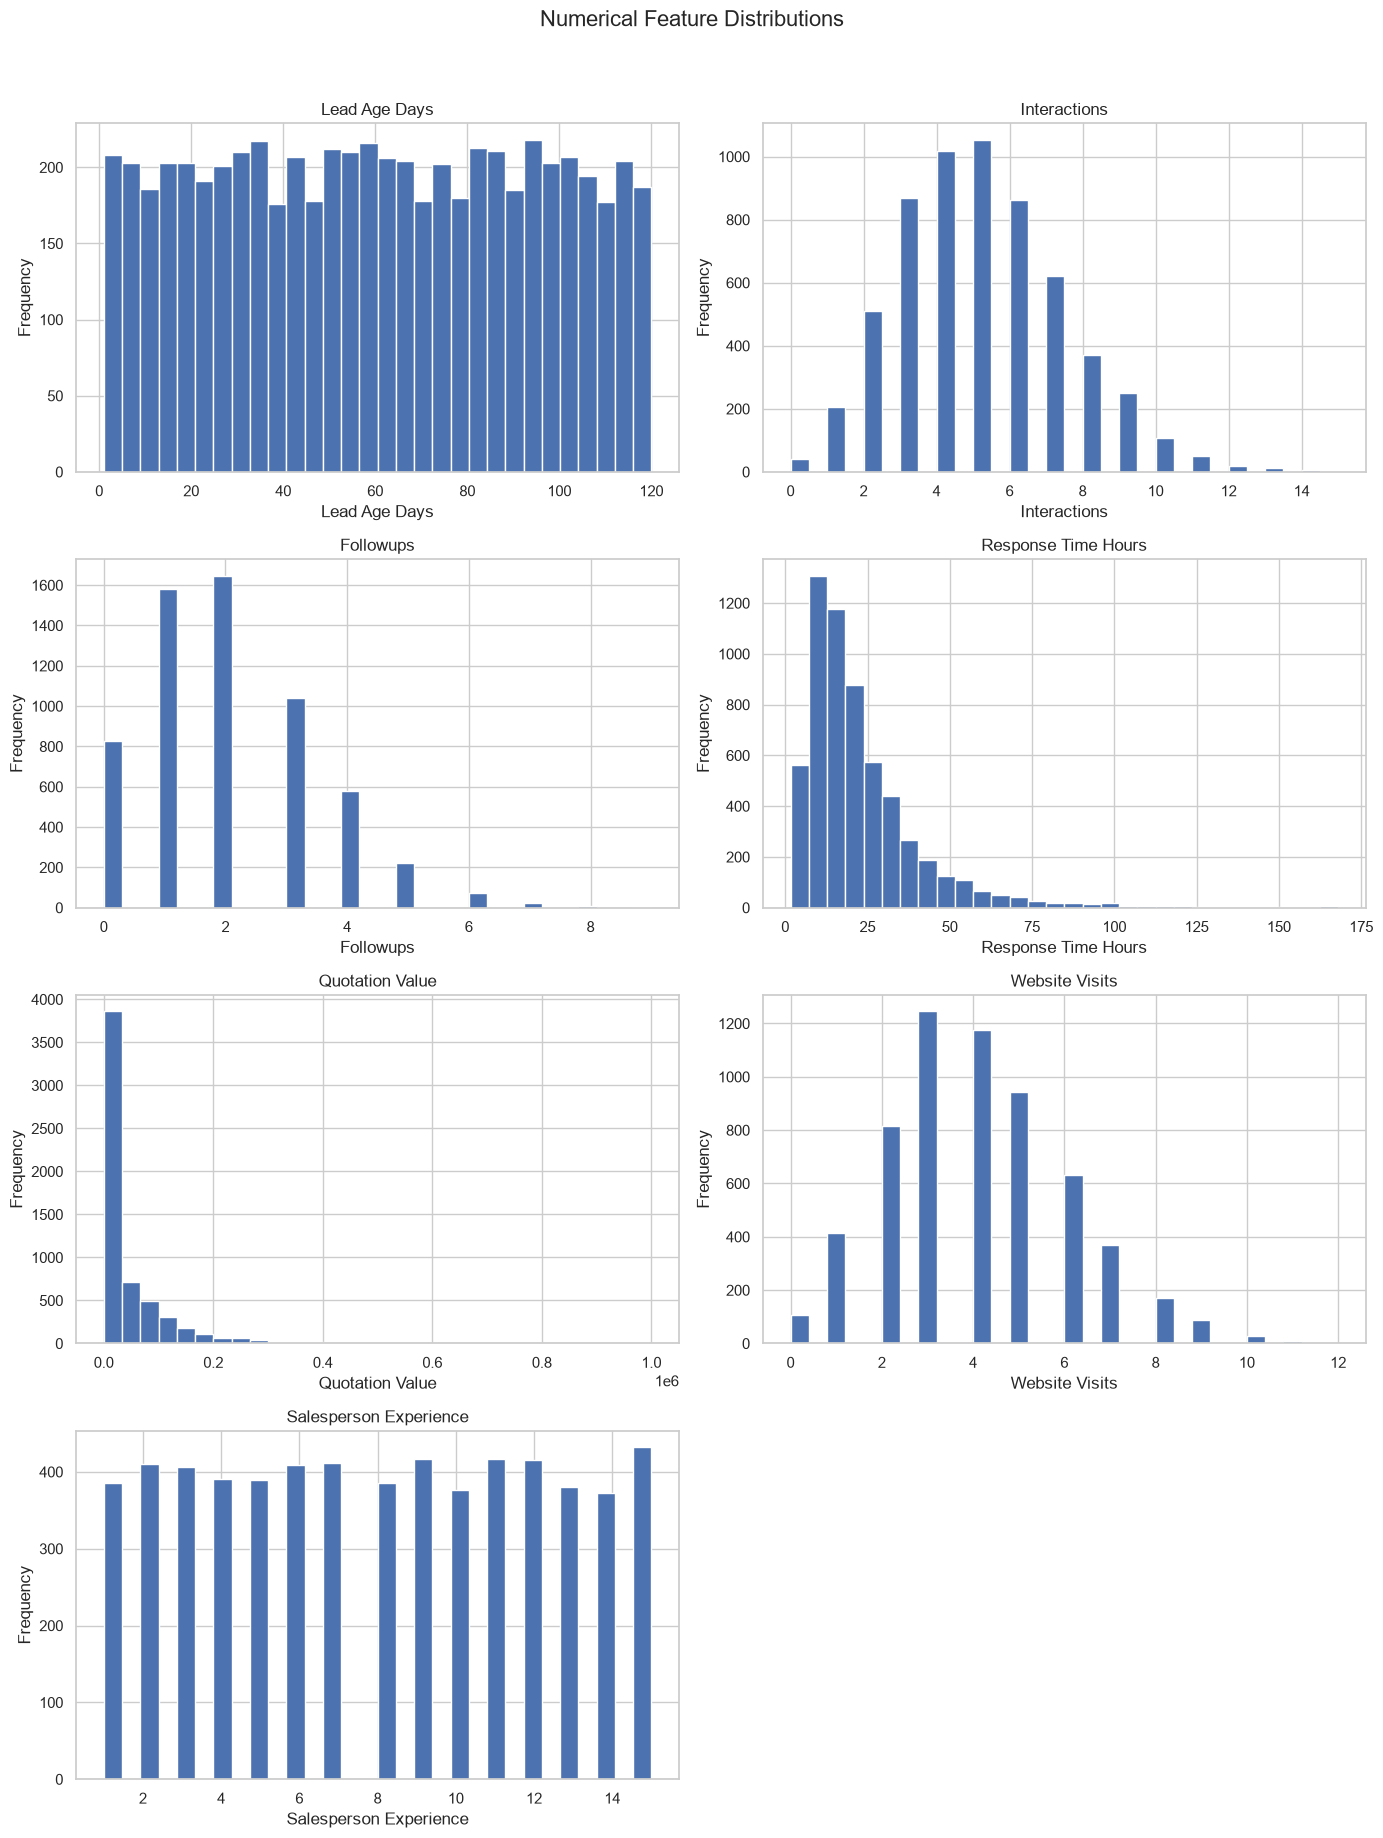

Saved figure: e:\lead-conversion-prediction\reports\figures\numerical_feature_distributions.png


In [12]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 18)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].hist(
        df[feature].dropna(),
        bins=30
    )
    
    axes[i].set_title(
        feature.replace("_", " ").title()
    )
    axes[i].set_xlabel(
        feature.replace("_", " ").title()
    )
    axes[i].set_ylabel("Frequency")

# Hide the unused eighth subplot
axes[-1].set_visible(False)

plt.suptitle(
    "Numerical Feature Distributions",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

numerical_distribution_figure = (
    FIGURES_DIR / "numerical_feature_distributions.png"
)

plt.savefig(
    numerical_distribution_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {numerical_distribution_figure}"
)

C:\Users\ASTARAG DISAI\AppData\Local\Temp\ipykernel_19692\3356572377.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(
C:\Users\ASTARAG DISAI\AppData\Local\Temp\ipykernel_19692\3356572377.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(
C:\Users\ASTARAG DISAI\AppData\Local\Temp\ipykernel_19692\3356572377.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(
C:\Users\ASTARAG DISAI\AppData\Local\Temp\ipykernel_19692\3356572377.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].b

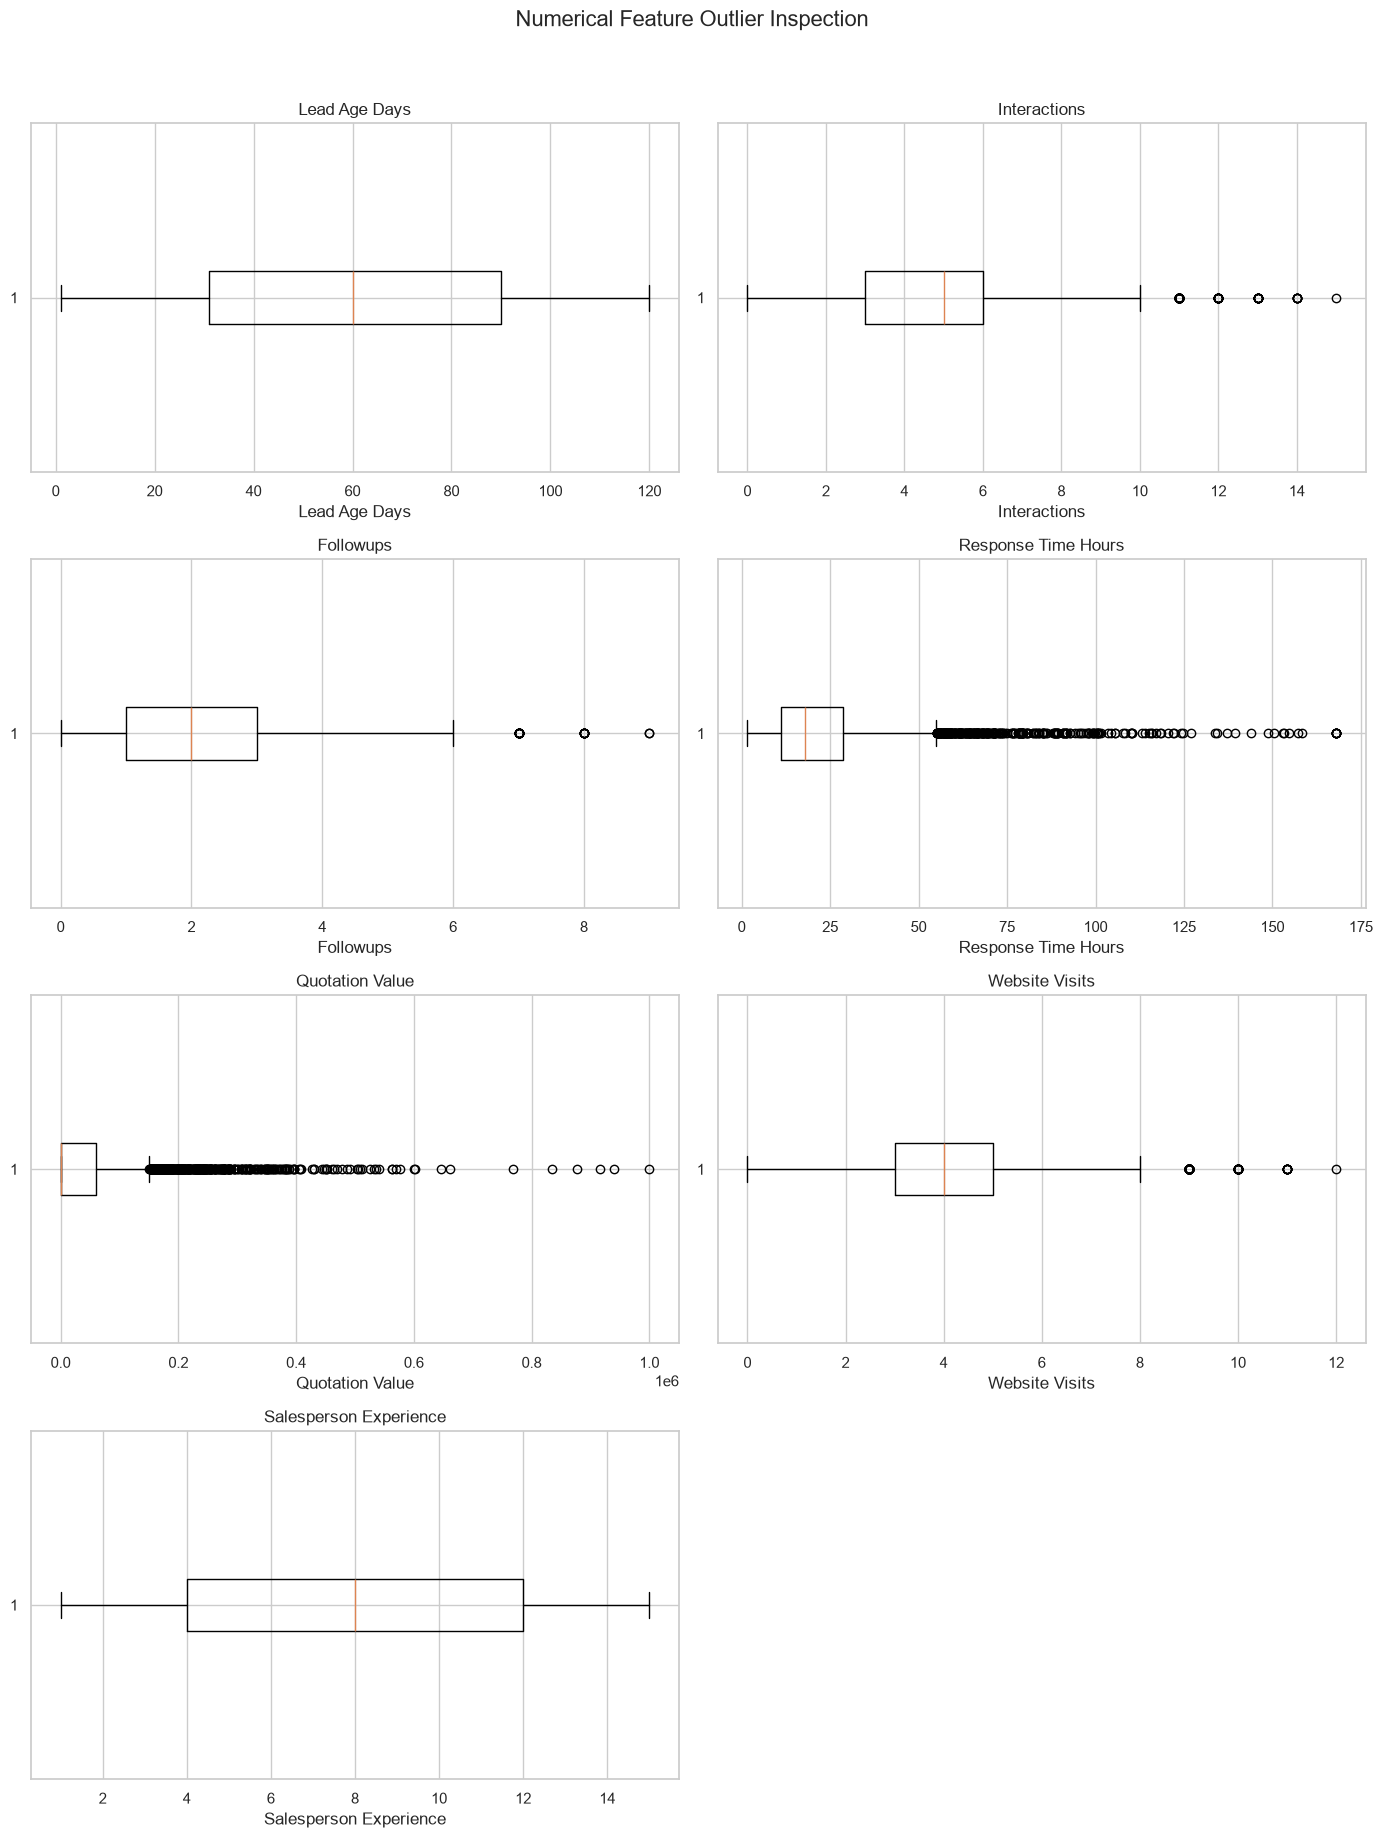

Saved figure: e:\lead-conversion-prediction\reports\figures\numerical_outlier_inspection.png


In [13]:
# STEP 11 — Numerical Outlier Inspection

fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 18)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].boxplot(
        df[feature].dropna(),
        vert=False
    )
    
    axes[i].set_title(
        feature.replace("_", " ").title()
    )
    axes[i].set_xlabel(
        feature.replace("_", " ").title()
    )

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle(
    "Numerical Feature Outlier Inspection",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

outlier_figure = (
    FIGURES_DIR / "numerical_outlier_inspection.png"
)

plt.savefig(
    outlier_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {outlier_figure}"
)

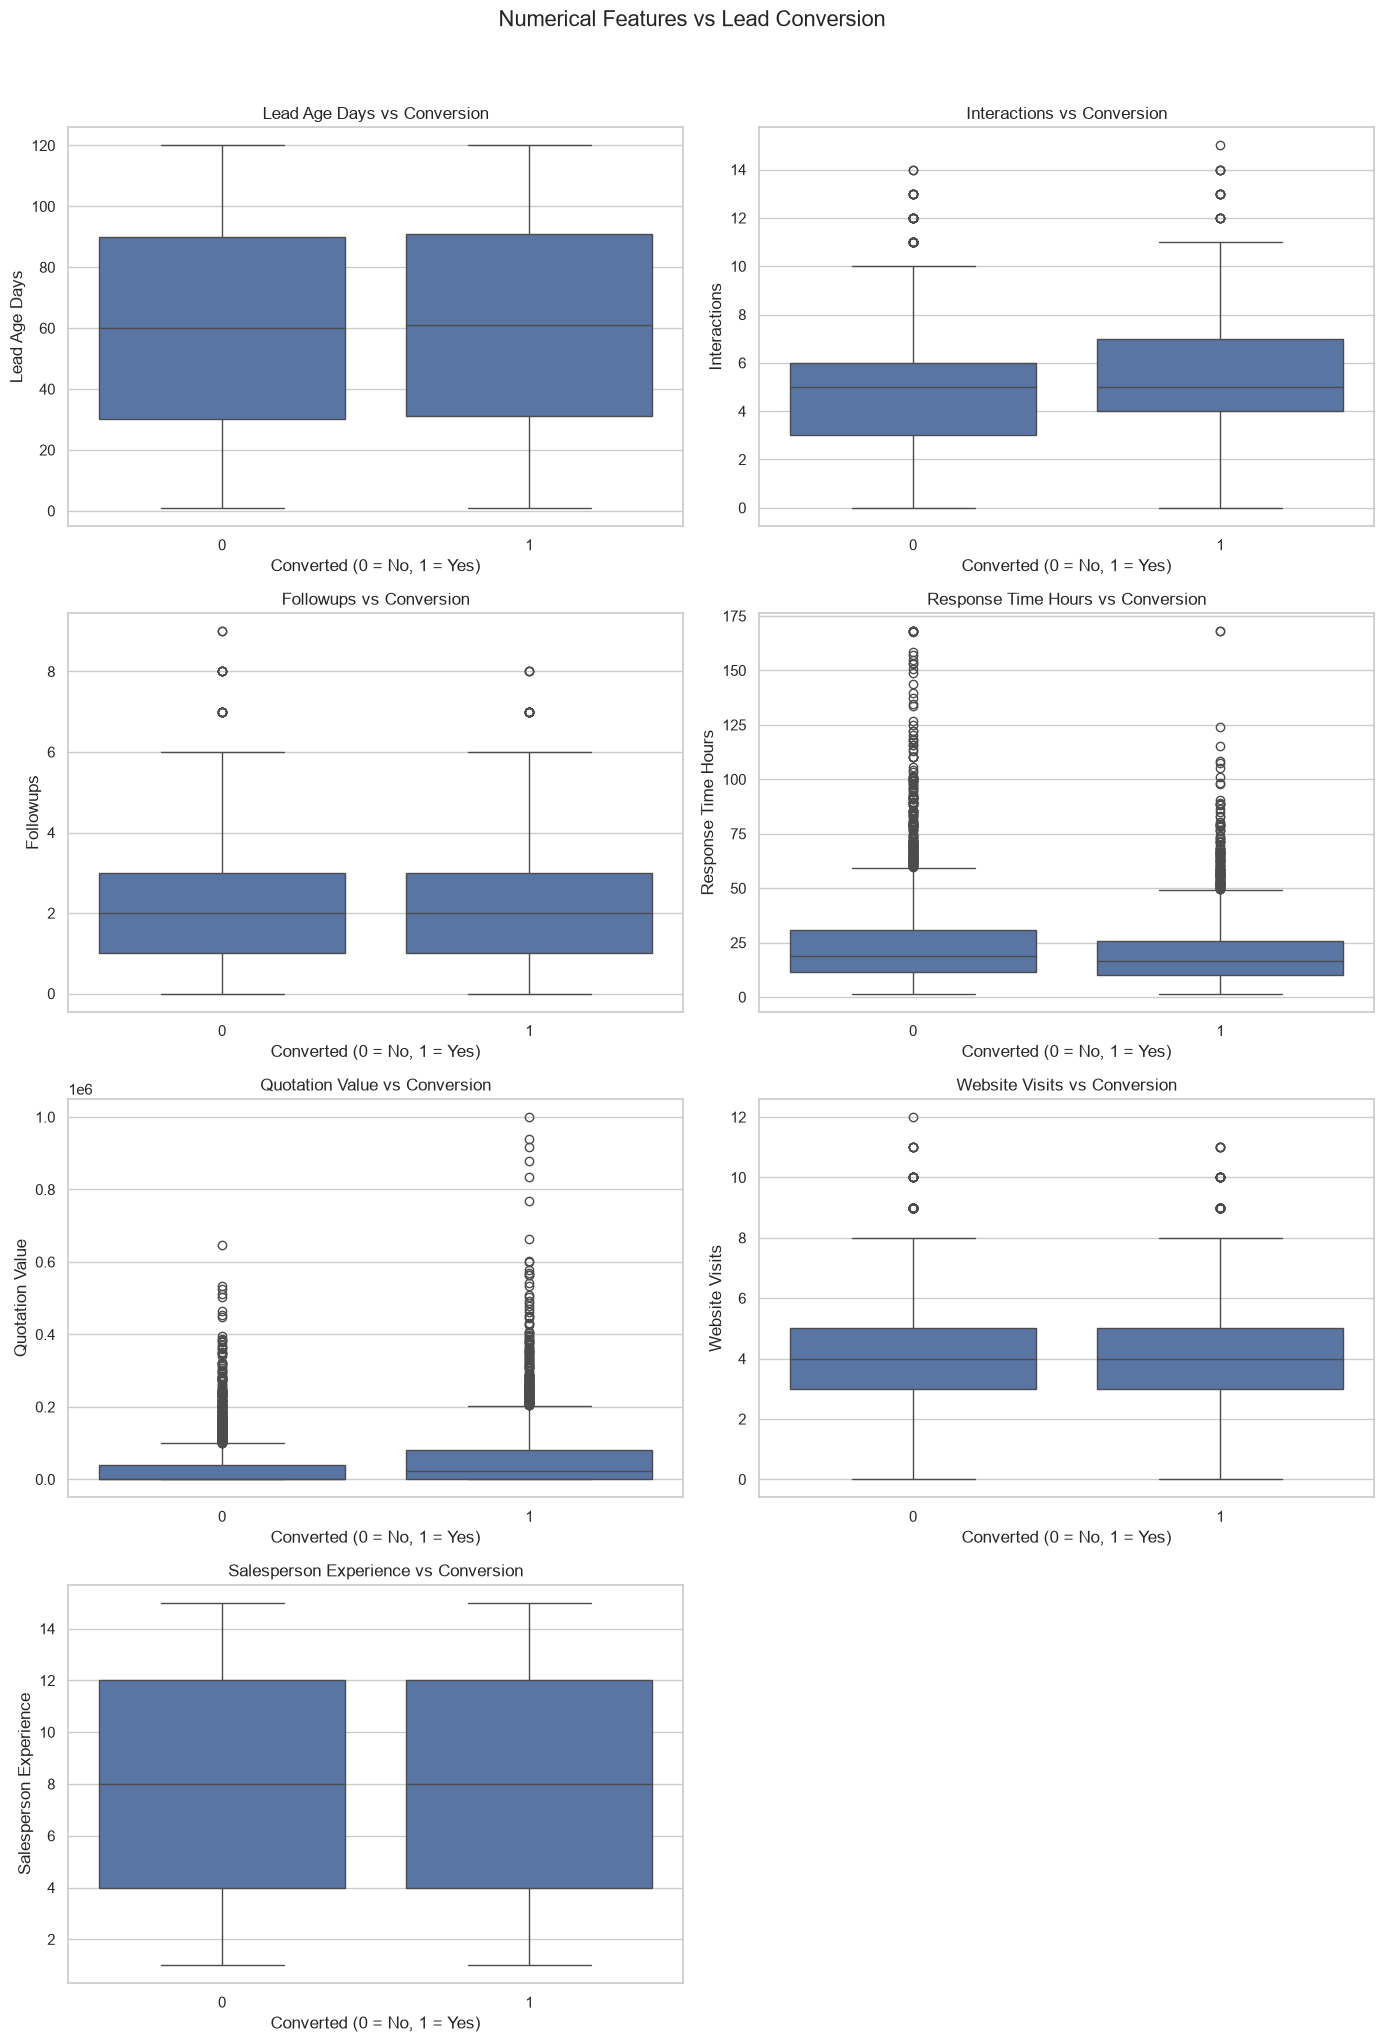

Saved figure: e:\lead-conversion-prediction\reports\figures\numerical_features_vs_conversion.png


In [14]:
# STEP 12 — Numerical Features vs Conversion

numerical_features = [
    "lead_age_days",
    "interactions",
    "followups",
    "response_time_hours",
    "quotation_value",
    "website_visits",
    "salesperson_experience"
]

fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 20)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        data=df,
        x="converted",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature.replace('_', ' ').title()} vs Conversion"
    )

    axes[i].set_xlabel(
        "Converted (0 = No, 1 = Yes)"
    )

    axes[i].set_ylabel(
        feature.replace("_", " ").title()
    )

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle(
    "Numerical Features vs Lead Conversion",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

feature_target_figure = (
    FIGURES_DIR / "numerical_features_vs_conversion.png"
)

plt.savefig(
    feature_target_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {feature_target_figure}"
)

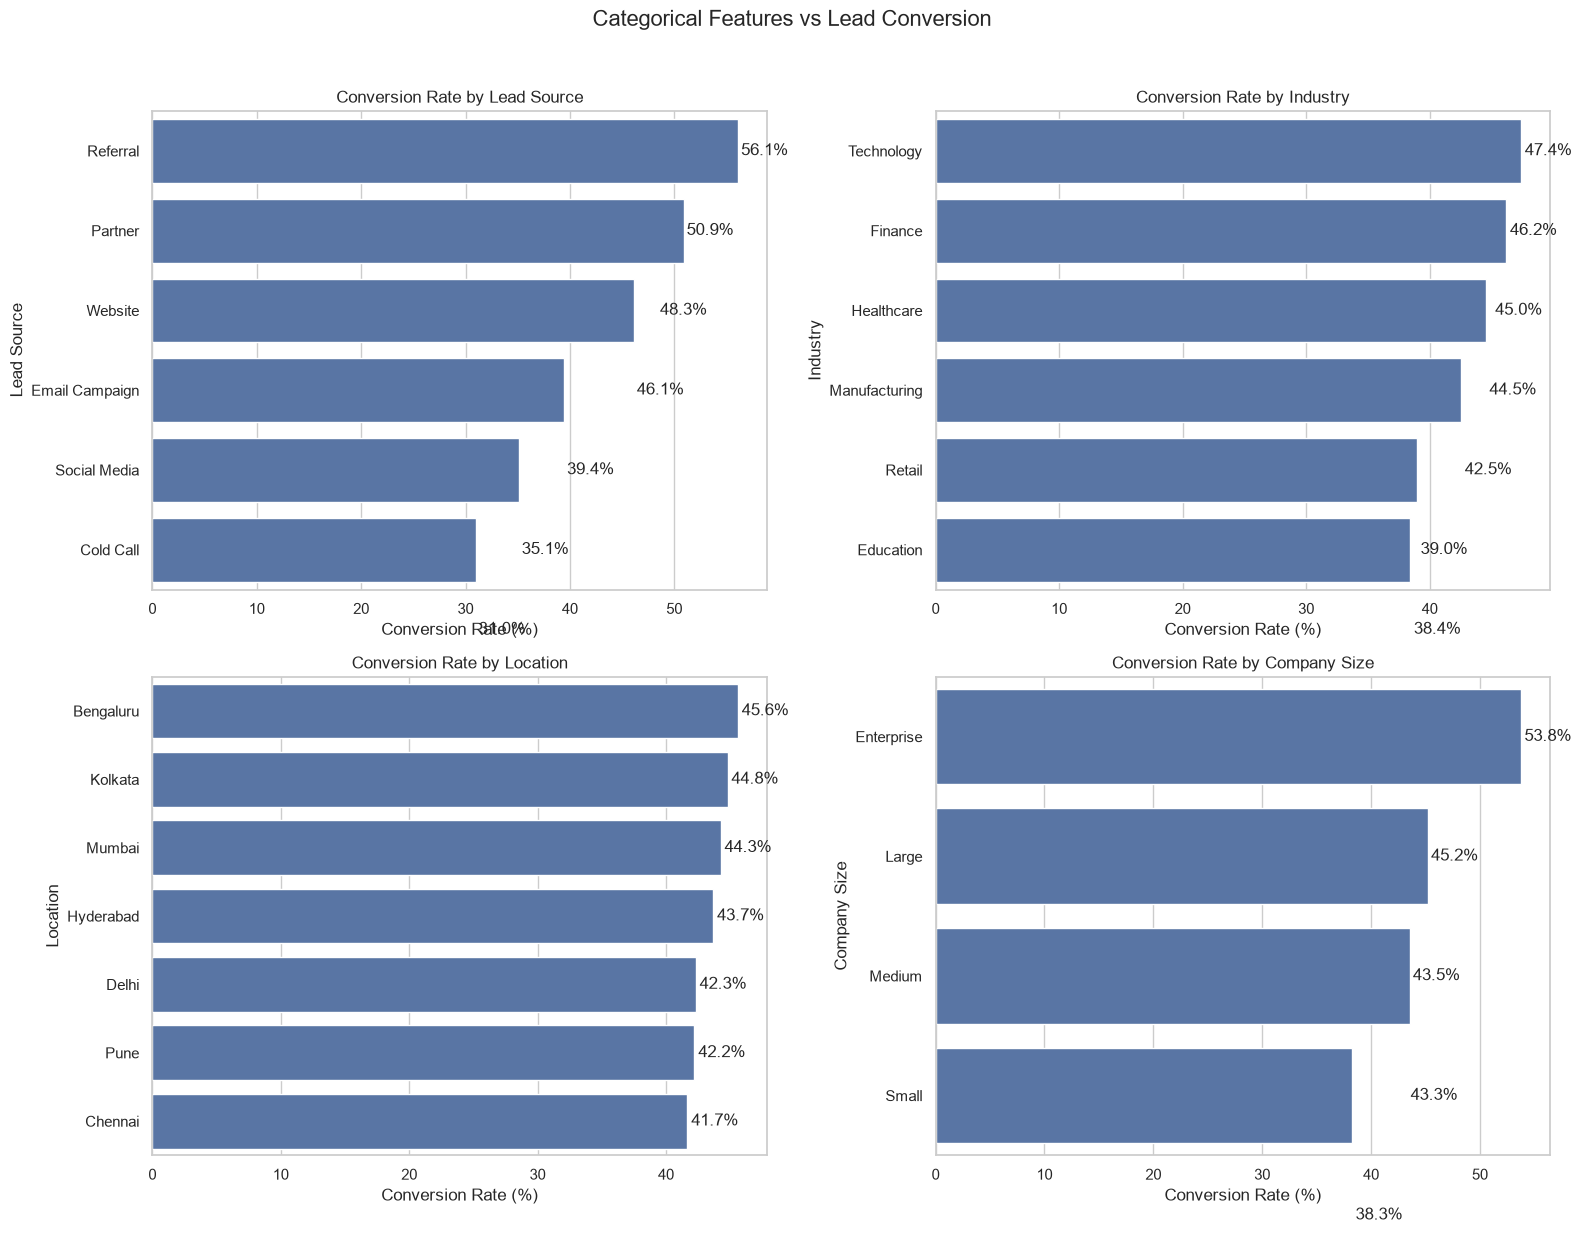

Saved figure: e:\lead-conversion-prediction\reports\figures\categorical_features_vs_conversion.png


In [15]:
# STEP 13 — Categorical Features vs Conversion

categorical_features = [
    "lead_source",
    "industry",
    "location",
    "company_size"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    conversion_rates = (
        df.groupby(feature, dropna=False)["converted"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    conversion_rates.index = conversion_rates.index.astype(str)

    sns.barplot(
        x=conversion_rates.values,
        y=conversion_rates.index,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Conversion Rate by {feature.replace('_', ' ').title()}"
    )

    axes[i].set_xlabel("Conversion Rate (%)")
    axes[i].set_ylabel(
        feature.replace("_", " ").title()
    )

    for j, value in enumerate(conversion_rates.values):
        axes[i].text(
            value + 0.3,
            j,
            f"{value:.1f}%",
            va="center"
        )

plt.suptitle(
    "Categorical Features vs Lead Conversion",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

categorical_target_figure = (
    FIGURES_DIR / "categorical_features_vs_conversion.png"
)

plt.savefig(
    categorical_target_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {categorical_target_figure}"
)

,spearman_correlation_with_converted
quotation_value,0.206672
quotation_sent,0.202412
previous_customer,0.134895
demo_attended,0.124533
interactions,0.065036
followups,0.046096
salesperson_experience,0.035126
lead_age_days,0.010858
website_visits,0.002463
response_time_hours,-0.100515


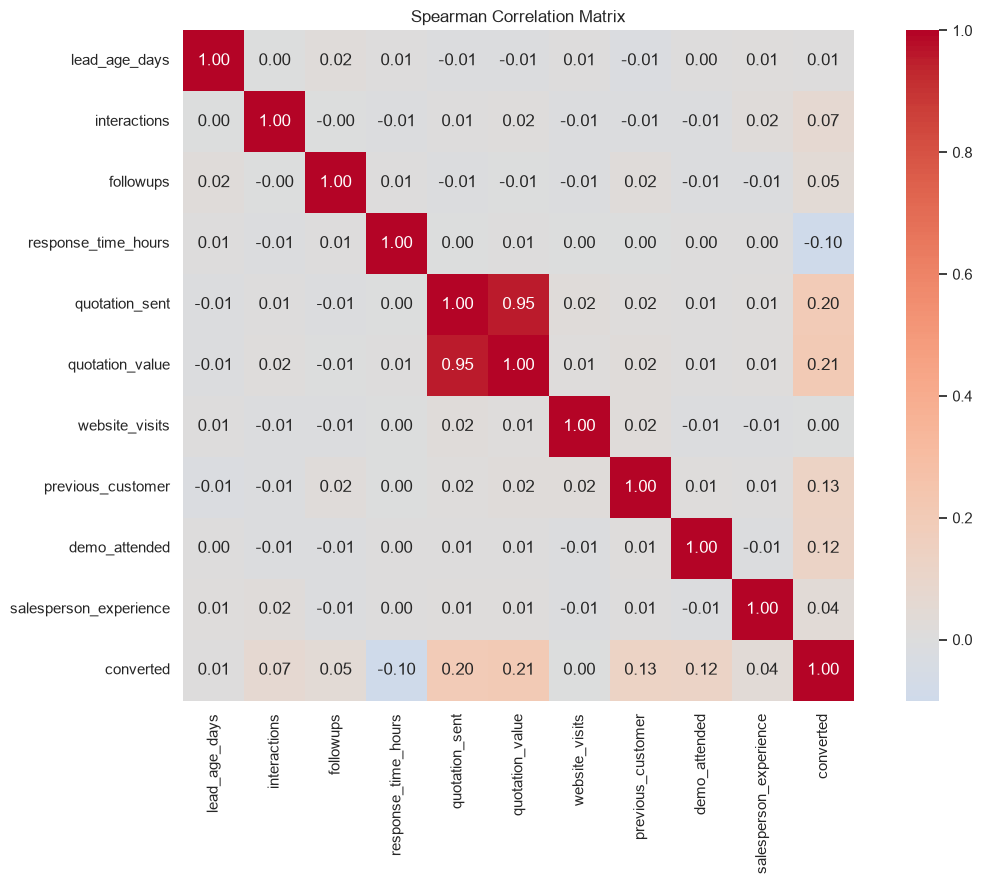

Saved figure: e:\lead-conversion-prediction\reports\figures\correlation_matrix.png


In [16]:
# STEP 14 — Numerical Correlation Analysis

numerical_features = [
    "lead_age_days",
    "interactions",
    "followups",
    "response_time_hours",
    "quotation_sent",
    "quotation_value",
    "website_visits",
    "previous_customer",
    "demo_attended",
    "salesperson_experience",
    "converted"
]

correlation_matrix = df[numerical_features].corr(
    method="spearman"
)

# Correlation of each numerical feature with the target
target_correlation = (
    correlation_matrix["converted"]
    .drop("converted")
    .sort_values(ascending=False)
)

display(
    target_correlation.to_frame(
        name="spearman_correlation_with_converted"
    )
)

# Plot correlation heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Spearman Correlation Matrix")

plt.tight_layout()

correlation_figure = (
    FIGURES_DIR / "correlation_matrix.png"
)

plt.savefig(
    correlation_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {correlation_figure}"
)

## 15. Exploratory Data Analysis — Key Findings

### Dataset Overview
- The validated dataset contains 6,000 leads and 16 columns.
- The target variable is `converted`.
- The dataset contains both numerical and categorical predictors.
- Missing values are present but remain low overall, with the highest missingness in `response_time_hours` at approximately 1.17%.

### Target Distribution
- 3,390 leads were not converted.
- 2,610 leads were converted.
- The conversion rate is approximately 43.5%.
- The target is moderately balanced and does not require aggressive class-balancing assumptions at this stage.

### Numerical Feature Observations
- `lead_age_days` is distributed across approximately 1–120 days.
- `interactions` and `followups` are concentrated around lower integer values.
- `response_time_hours` is right-skewed and contains substantial high-value outliers.
- `quotation_value` is strongly right-skewed with many zero values and several high-value observations.
- `website_visits` is concentrated around a small number of visits.
- `salesperson_experience` spans approximately 1–15 years.

### Categorical Feature Observations
- Conversion rates vary across lead sources, industries, locations, and company sizes.
- Lead source shows noticeable variation in observed conversion rates.
- Company size also shows variation in observed conversion rates.
- These relationships will be encoded and evaluated by the machine-learning pipeline rather than manually converted into rules.

### Correlation Findings
- `quotation_value` and `quotation_sent` show the strongest positive numerical relationships with conversion.
- `previous_customer` and `demo_attended` also show positive relationships with conversion.
- `response_time_hours` shows a modest negative relationship with conversion.
- Other numerical variables show relatively weak individual monotonic relationships with the target.
- `quotation_sent` and `quotation_value` are highly correlated with each other, with a Spearman correlation of approximately 0.95.
- Correlation alone will not be used to eliminate features because machine-learning models can capture nonlinear and combined effects.

### EDA Conclusion
The dataset is suitable for supervised binary classification after preprocessing.

The next stage is to build a reproducible machine-learning preprocessing pipeline that:
1. separates features and target,
2. handles missing values,
3. encodes categorical variables,
4. prepares numerical features,
5. performs a stratified train/test split,
6. prevents data leakage,
7. and prepares the data for baseline model training.

In [17]:
# STEP 16 — Prepare Features and Target + Stratified Train/Test Split

from sklearn.model_selection import train_test_split

# Separate target from input features
X = df.drop(columns=["converted", "lead_id"])
y = df["converted"]

# Stratified split preserves the conversion ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nTest set:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print("\nTarget distribution:")

distribution = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).sort_index()

distribution.index = ["Not Converted (0)", "Converted (1)"]

display(
    (distribution * 100).round(2)
)

Training set:
X_train: (4800, 14)
y_train: (4800,)

Test set:
X_test: (1200, 14)
y_test: (1200,)

Target distribution:


,Train,Test
Not Converted (0),56.5,56.5
Converted (1),43.5,43.5


In [22]:
# STEP 17 — Leakage-Safe Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# 1. Identify feature types
# ------------------------------------------------------------

categorical_features = [
    "lead_source",
    "industry",
    "location",
    "company_size"
]

numerical_features = [
    "lead_age_days",
    "interactions",
    "followups",
    "response_time_hours",
    "quotation_sent",
    "quotation_value",
    "website_visits",
    "previous_customer",
    "demo_attended",
    "salesperson_experience"
]

# ------------------------------------------------------------
# 2. Numerical preprocessing
#    - Median imputation
#    - Standard scaling
# ------------------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ------------------------------------------------------------
# 3. Categorical preprocessing
#    - Most frequent imputation
#    - One-hot encoding
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# ------------------------------------------------------------
# 4. Combine preprocessing pipelines
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

# ------------------------------------------------------------
# 5. Fit ONLY on training data
# ------------------------------------------------------------

X_train_processed = preprocessor.fit_transform(
    X_train
)

# ------------------------------------------------------------
# 6. Transform test data using fitted preprocessor
# ------------------------------------------------------------

X_test_processed = preprocessor.transform(
    X_test
)

# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

print("Preprocessing completed successfully.")

print(f"\nOriginal feature count: {X_train.shape[1]}")
print(f"Processed feature count: {X_train_processed.shape[1]}")

print(
    f"\nX_train_processed shape: "
    f"{X_train_processed.shape}"
)

print(
    f"X_test_processed shape: "
    f"{X_test_processed.shape}"
)

print(
    f"\nMissing values after preprocessing — "
    f"train: "
    f"{int(pd.DataFrame(X_train_processed).isna().sum().sum())}"
)

print(
    f"Missing values after preprocessing — "
    f"test: "
    f"{int(pd.DataFrame(X_test_processed).isna().sum().sum())}"
)

print("\nNumerical features: imputed + standardized.")
print("Categorical features: imputed + one-hot encoded.")
print("Leakage-safe preprocessing pipeline ready.")

Preprocessing completed successfully.

Original feature count: 14
Processed feature count: 33

X_train_processed shape: (4800, 33)
X_test_processed shape: (1200, 33)

Missing values after preprocessing — train: 0
Missing values after preprocessing — test: 0

Numerical features: imputed + standardized.
Categorical features: imputed + one-hot encoded.
Leakage-safe preprocessing pipeline ready.


In [23]:
# STEP 18 — Baseline Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ------------------------------------------------------------
# 1. Initialize baseline model
# ------------------------------------------------------------

baseline_model = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    random_state=42
)

# ------------------------------------------------------------
# 2. Train
# ------------------------------------------------------------

baseline_model.fit(
    X_train_processed,
    y_train
)

# ------------------------------------------------------------
# 3. Predictions
# ------------------------------------------------------------

y_train_pred = baseline_model.predict(
    X_train_processed
)

y_test_pred = baseline_model.predict(
    X_test_processed
)

# Probability of Converted class
y_train_proba = baseline_model.predict_proba(
    X_train_processed
)[:, 1]

y_test_proba = baseline_model.predict_proba(
    X_test_processed
)[:, 1]

# ------------------------------------------------------------
# 4. Evaluation function
# ------------------------------------------------------------

def evaluate_model(
    y_true,
    y_pred,
    y_proba,
    dataset_name
):

    print("=" * 55)
    print(f"{dataset_name} Performance")
    print("=" * 55)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

# ------------------------------------------------------------
# 5. Training performance
# ------------------------------------------------------------

train_metrics = evaluate_model(
    y_train,
    y_train_pred,
    y_train_proba,
    "Training Set"
)

# ------------------------------------------------------------
# 6. Test performance
# ------------------------------------------------------------

test_metrics = evaluate_model(
    y_test,
    y_test_pred,
    y_test_proba,
    "Test Set"
)

# ------------------------------------------------------------
# 7. Classification report
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("Classification Report — Test Set")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Not Converted",
            "Converted"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 8. Completion status
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("Baseline Logistic Regression completed successfully.")
print("=" * 55)

Training Set Performance
Accuracy : 0.6608
Precision: 0.6371
Recall   : 0.5120
F1 Score : 0.5677
ROC-AUC  : 0.7083
Test Set Performance
Accuracy : 0.6783
Precision: 0.6553
Recall   : 0.5498
F1 Score : 0.5979
ROC-AUC  : 0.7317

Classification Report — Test Set
               precision    recall  f1-score   support

Not Converted       0.69      0.78      0.73       678
    Converted       0.66      0.55      0.60       522

     accuracy                           0.68      1200
    macro avg       0.67      0.66      0.66      1200
 weighted avg       0.68      0.68      0.67      1200


Baseline Logistic Regression completed successfully.


In [24]:
# STEP 19 — Decision Tree Baseline

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Initialize Decision Tree
# ------------------------------------------------------------

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10
)

# ------------------------------------------------------------
# 2. Train
# ------------------------------------------------------------

decision_tree_model.fit(
    X_train_processed,
    y_train
)

# ------------------------------------------------------------
# 3. Predictions
# ------------------------------------------------------------

y_train_dt_pred = decision_tree_model.predict(
    X_train_processed
)

y_test_dt_pred = decision_tree_model.predict(
    X_test_processed
)

# Probability of Converted class
y_train_dt_proba = decision_tree_model.predict_proba(
    X_train_processed
)[:, 1]

y_test_dt_proba = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

# ------------------------------------------------------------
# 4. Evaluation function
# ------------------------------------------------------------

def evaluate_decision_tree(
    y_true,
    y_pred,
    y_proba,
    dataset_name
):

    print("=" * 55)
    print(f"{dataset_name} Performance")
    print("=" * 55)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }


# ------------------------------------------------------------
# 5. Training performance
# ------------------------------------------------------------

decision_tree_train_metrics = evaluate_decision_tree(
    y_train,
    y_train_dt_pred,
    y_train_dt_proba,
    "Decision Tree — Training Set"
)

# ------------------------------------------------------------
# 6. Test performance
# ------------------------------------------------------------

decision_tree_test_metrics = evaluate_decision_tree(
    y_test,
    y_test_dt_pred,
    y_test_dt_proba,
    "Decision Tree — Test Set"
)

# ------------------------------------------------------------
# 7. Classification report
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("Decision Tree Classification Report — Test Set")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_test_dt_pred,
        target_names=[
            "Not Converted",
            "Converted"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 8. Confusion matrix
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("Decision Tree Confusion Matrix")
print("=" * 55)

print(
    confusion_matrix(
        y_test,
        y_test_dt_pred
    )
)

# ------------------------------------------------------------
# 9. Completion status
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("Decision Tree baseline completed successfully.")
print("=" * 55)

Decision Tree — Training Set Performance
Accuracy : 0.6608
Precision: 0.6450
Recall   : 0.4899
F1 Score : 0.5569
ROC-AUC  : 0.7070
Decision Tree — Test Set Performance
Accuracy : 0.6492
Precision: 0.6292
Recall   : 0.4713
F1 Score : 0.5389
ROC-AUC  : 0.6630

Decision Tree Classification Report — Test Set
               precision    recall  f1-score   support

Not Converted       0.66      0.79      0.72       678
    Converted       0.63      0.47      0.54       522

     accuracy                           0.65      1200
    macro avg       0.64      0.63      0.63      1200
 weighted avg       0.65      0.65      0.64      1200


Decision Tree Confusion Matrix
[[533 145]
 [276 246]]

Decision Tree baseline completed successfully.


In [25]:
# STEP 20 — Random Forest Baseline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Initialize Random Forest
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 2. Train
# ------------------------------------------------------------

random_forest_model.fit(
    X_train_processed,
    y_train
)

# ------------------------------------------------------------
# 3. Predictions
# ------------------------------------------------------------

y_train_rf_pred = random_forest_model.predict(
    X_train_processed
)

y_test_rf_pred = random_forest_model.predict(
    X_test_processed
)

# Probability of Converted class
y_train_rf_proba = random_forest_model.predict_proba(
    X_train_processed
)[:, 1]

y_test_rf_proba = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

# ------------------------------------------------------------
# 4. Evaluation function
# ------------------------------------------------------------

def evaluate_random_forest(
    y_true,
    y_pred,
    y_proba,
    dataset_name
):

    print("=" * 55)
    print(f"{dataset_name} Performance")
    print("=" * 55)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }


# ------------------------------------------------------------
# 5. Training performance
# ------------------------------------------------------------

random_forest_train_metrics = evaluate_random_forest(
    y_train,
    y_train_rf_pred,
    y_train_rf_proba,
    "Random Forest — Training Set"
)

# ------------------------------------------------------------
# 6. Test performance
# ------------------------------------------------------------

random_forest_test_metrics = evaluate_random_forest(
    y_test,
    y_test_rf_pred,
    y_test_rf_proba,
    "Random Forest — Test Set"
)

# ------------------------------------------------------------
# 7. Classification report
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("Random Forest Classification Report — Test Set")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_test_rf_pred,
        target_names=[
            "Not Converted",
            "Converted"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 8. Confusion matrix
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("Random Forest Confusion Matrix")
print("=" * 55)

print(
    confusion_matrix(
        y_test,
        y_test_rf_pred
    )
)

# ------------------------------------------------------------
# 9. Completion status
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("Random Forest baseline completed successfully.")
print("=" * 55)

Random Forest — Training Set Performance
Accuracy : 0.7360
Precision: 0.6860
Recall   : 0.7251
F1 Score : 0.7050
ROC-AUC  : 0.8206
Random Forest — Test Set Performance
Accuracy : 0.6525
Precision: 0.5897
Recall   : 0.6609
F1 Score : 0.6233
ROC-AUC  : 0.7239

Random Forest Classification Report — Test Set
               precision    recall  f1-score   support

Not Converted       0.71      0.65      0.68       678
    Converted       0.59      0.66      0.62       522

     accuracy                           0.65      1200
    macro avg       0.65      0.65      0.65      1200
 weighted avg       0.66      0.65      0.65      1200


Random Forest Confusion Matrix
[[438 240]
 [177 345]]

Random Forest baseline completed successfully.


In [27]:
# STEP 21 — Baseline Model Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.6783,
        0.6492,
        0.6525
    ],
    "Precision": [
        0.6553,
        0.6292,
        0.5897
    ],
    "Recall": [
        0.5498,
        0.4713,
        0.6609
    ],
    "F1 Score": [
        0.5979,
        0.5389,
        0.6233
    ],
    "ROC-AUC": [
        0.7317,
        0.6630,
        0.7239
    ]
})

display(
    model_comparison.round(4)
)

print("\nBaseline model comparison completed successfully.")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6783,0.6553,0.5498,0.5979,0.7317
1,Decision Tree,0.6492,0.6292,0.4713,0.5389,0.6630
2,Random Forest,0.6525,0.5897,0.6609,0.6233,0.7239



Baseline model comparison completed successfully.


In [28]:
# STEP 22 — Random Forest Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# 1. Define parameter grid
# ------------------------------------------------------------

rf_parameter_grid = {
    "n_estimators": [200, 300],
    "max_depth": [6, 10, 14],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [5, 10]
}

# ------------------------------------------------------------
# 2. Base model
# ------------------------------------------------------------

rf_tuning_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 3. Grid Search
# ------------------------------------------------------------

rf_grid_search = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=rf_parameter_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------------------------
# 4. Fit ONLY on training data
# ------------------------------------------------------------

rf_grid_search.fit(
    X_train_processed,
    y_train
)

# ------------------------------------------------------------
# 5. Best configuration
# ------------------------------------------------------------

print("=" * 60)
print("Random Forest Hyperparameter Tuning")
print("=" * 60)

print("\nBest Parameters:")
print(rf_grid_search.best_params_)

print(
    f"\nBest Cross-Validation ROC-AUC: "
    f"{rf_grid_search.best_score_:.4f}"
)

print("\nRandom Forest tuning completed successfully.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Random Forest Hyperparameter Tuning

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}

Best Cross-Validation ROC-AUC: 0.6844

Random Forest tuning completed successfully.


In [29]:
# STEP 23 — Tuned Random Forest Final Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Get the best model from GridSearchCV
# ------------------------------------------------------------

tuned_random_forest = rf_grid_search.best_estimator_

# ------------------------------------------------------------
# 2. Test-set predictions
# ------------------------------------------------------------

y_test_tuned_rf_pred = tuned_random_forest.predict(
    X_test_processed
)

y_test_tuned_rf_proba = tuned_random_forest.predict_proba(
    X_test_processed
)[:, 1]

# ------------------------------------------------------------
# 3. Calculate final test metrics
# ------------------------------------------------------------

tuned_rf_accuracy = accuracy_score(
    y_test,
    y_test_tuned_rf_pred
)

tuned_rf_precision = precision_score(
    y_test,
    y_test_tuned_rf_pred,
    zero_division=0
)

tuned_rf_recall = recall_score(
    y_test,
    y_test_tuned_rf_pred,
    zero_division=0
)

tuned_rf_f1 = f1_score(
    y_test,
    y_test_tuned_rf_pred,
    zero_division=0
)

tuned_rf_roc_auc = roc_auc_score(
    y_test,
    y_test_tuned_rf_proba
)

# ------------------------------------------------------------
# 4. Display final performance
# ------------------------------------------------------------

print("=" * 60)
print("TUNED RANDOM FOREST — FINAL TEST PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {tuned_rf_accuracy:.4f}")
print(f"Precision: {tuned_rf_precision:.4f}")
print(f"Recall   : {tuned_rf_recall:.4f}")
print(f"F1 Score : {tuned_rf_f1:.4f}")
print(f"ROC-AUC  : {tuned_rf_roc_auc:.4f}")

# ------------------------------------------------------------
# 5. Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Classification Report — Tuned Random Forest")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_test_tuned_rf_pred,
        target_names=[
            "Not Converted",
            "Converted"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Confusion Matrix — Tuned Random Forest")
print("=" * 60)

print(
    confusion_matrix(
        y_test,
        y_test_tuned_rf_pred
    )
)

print("\nTuned Random Forest final evaluation completed successfully.")

TUNED RANDOM FOREST — FINAL TEST PERFORMANCE
Accuracy : 0.6483
Precision: 0.5868
Recall   : 0.6475
F1 Score : 0.6157
ROC-AUC  : 0.7220

Classification Report — Tuned Random Forest
               precision    recall  f1-score   support

Not Converted       0.71      0.65      0.68       678
    Converted       0.59      0.65      0.62       522

     accuracy                           0.65      1200
    macro avg       0.65      0.65      0.65      1200
 weighted avg       0.65      0.65      0.65      1200


Confusion Matrix — Tuned Random Forest
[[440 238]
 [184 338]]

Tuned Random Forest final evaluation completed successfully.


TOP FEATURES — TUNED RANDOM FOREST


,Feature,Importance
3,numerical__response_time_hours,0.1334
5,numerical__quotation_value,0.1195
0,numerical__lead_age_days,0.0876
4,numerical__quotation_sent,0.0678
9,numerical__salesperson_experience,0.0671
1,numerical__interactions,0.0589
7,numerical__previous_customer,0.0475
6,numerical__website_visits,0.0454
8,numerical__demo_attended,0.0443
2,numerical__followups,0.0418


FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/random_forest_feature_importance.png'

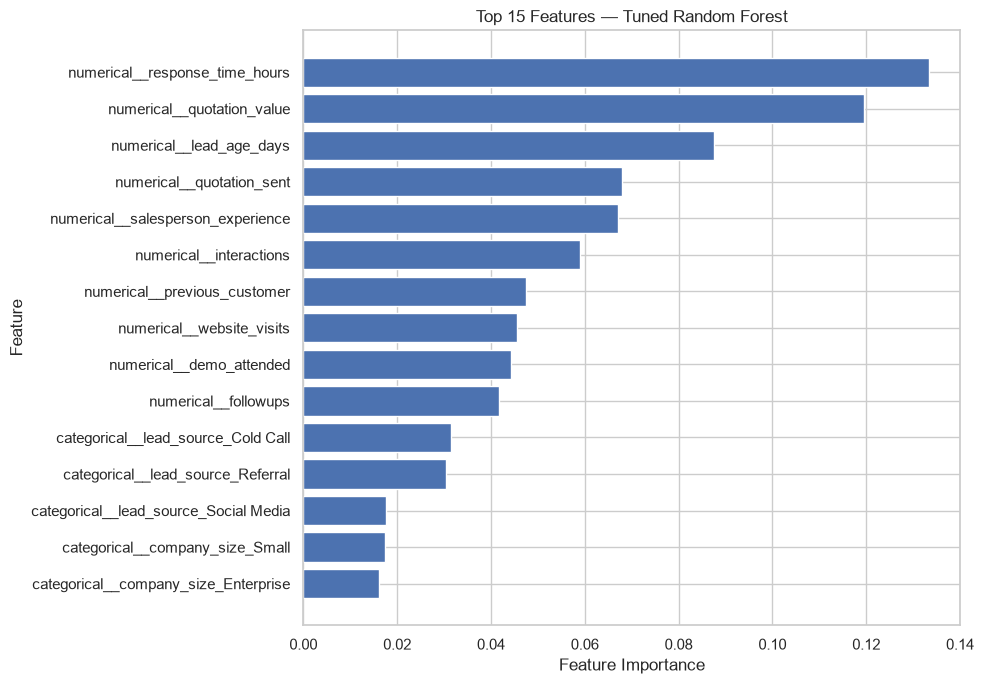

In [30]:
# STEP 24 — Tuned Random Forest Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Get feature names after preprocessing
# ------------------------------------------------------------

feature_names = preprocessor.get_feature_names_out()

# ------------------------------------------------------------
# Extract feature importance
# ------------------------------------------------------------

feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": tuned_random_forest.feature_importances_
    }
).sort_values(
    by="Importance",
    ascending=False
)

# ------------------------------------------------------------
# Display top features
# ------------------------------------------------------------

print("=" * 60)
print("TOP FEATURES — TUNED RANDOM FOREST")
print("=" * 60)

display(
    feature_importance.head(15).round(4)
)

# ------------------------------------------------------------
# Plot top 15 features
# ------------------------------------------------------------

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Tuned Random Forest")

plt.tight_layout()

feature_importance_figure = (
    "reports/figures/random_forest_feature_importance.png"
)

plt.savefig(
    feature_importance_figure,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nSaved figure: {feature_importance_figure}"
)

print(
    "\nFeature importance analysis completed successfully."
)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6783,0.6553,0.5498,0.5979,0.7317
1,Decision Tree,0.6492,0.6292,0.4713,0.5389,0.6630
2,Random Forest,0.6525,0.5897,0.6609,0.6233,0.7239
3,Tuned Random Forest,0.6483,0.5868,0.6475,0.6157,0.7220


FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/model_performance_comparison.png'

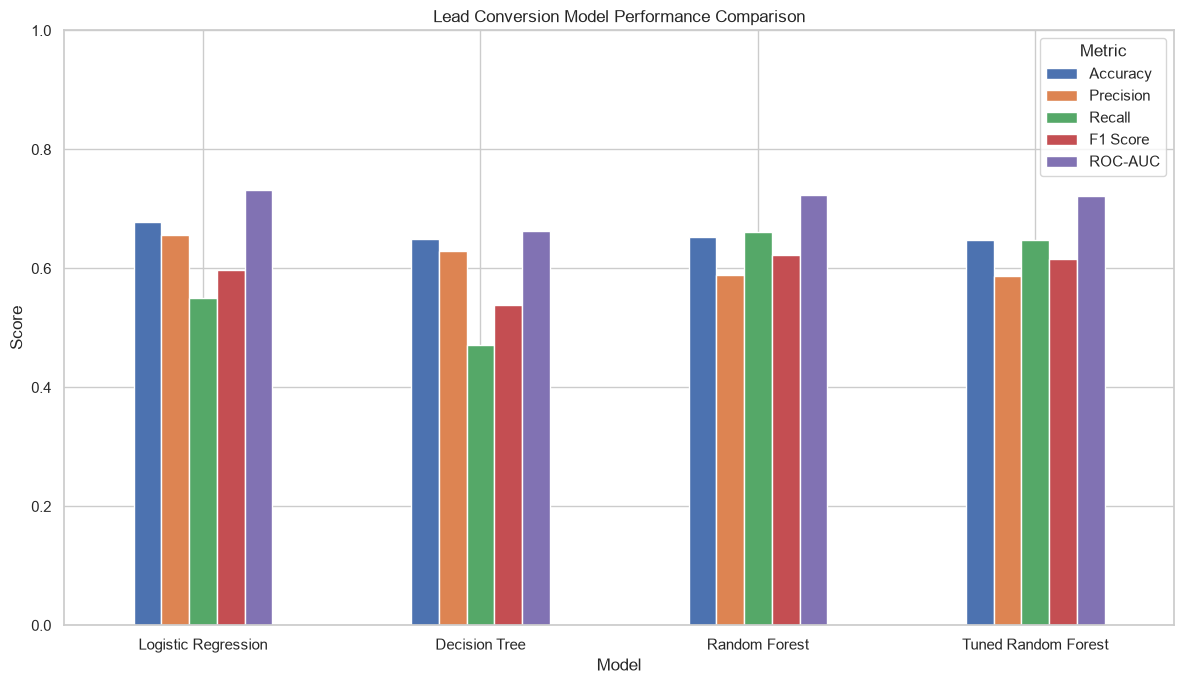

In [32]:
# STEP 25 — Final Model Comparison Visualization

import matplotlib.pyplot as plt
import pandas as pd

# The baseline model comparison already exists from the previous cell.
# Add the tuned Random Forest results obtained in Step 28/29.

final_model_comparison = model_comparison.copy()

tuned_rf_row = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [0.6483],
    "Precision": [0.5868],
    "Recall": [0.6475],
    "F1 Score": [0.6157],
    "ROC-AUC": [0.7220]
})

final_model_comparison = pd.concat(
    [final_model_comparison, tuned_rf_row],
    ignore_index=True
)

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(final_model_comparison.round(4))

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_plot = final_model_comparison.set_index("Model")[metrics]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

ax.set_title("Lead Conversion Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

model_comparison_figure = (
    "reports/figures/model_performance_comparison.png"
)

plt.savefig(
    model_comparison_figure,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nSaved figure: {model_comparison_figure}"
)

print(
    "\nFinal model comparison completed successfully."
)

FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/roc_curve_comparison.png'

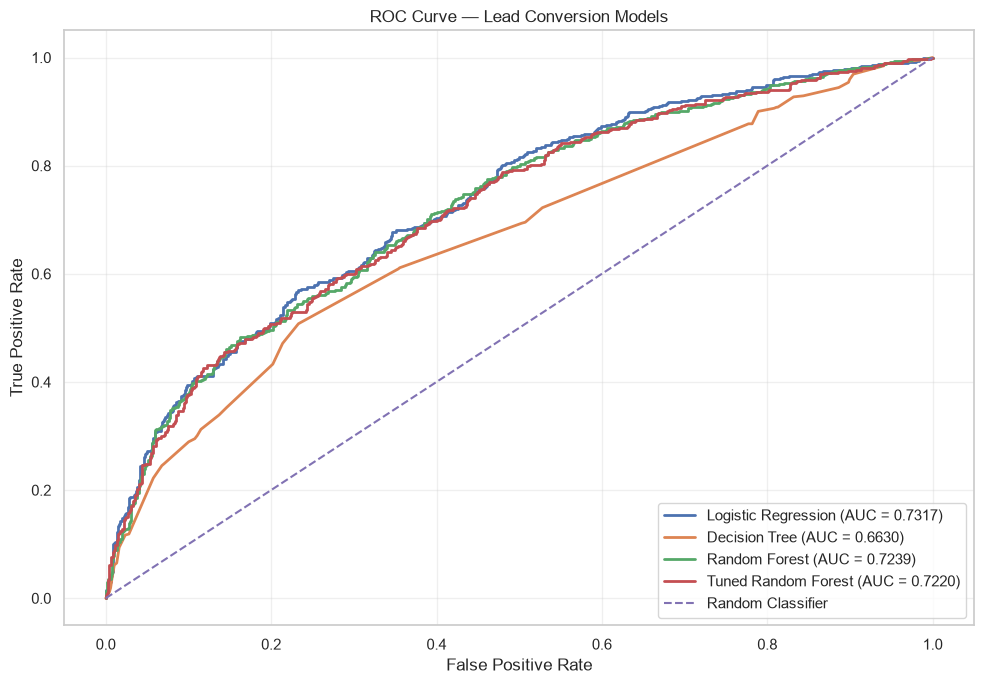

In [34]:
# STEP 26 — ROC-AUC Curve Comparison
# Uses the already-trained models from the notebook

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# ------------------------------------------------------------
# Locate already-trained models
# ------------------------------------------------------------

all_objects = globals()

# Logistic Regression
lr_candidates = [
    obj for obj in all_objects.values()
    if isinstance(obj, LogisticRegression)
]

# Decision Tree
dt_candidates = [
    obj for obj in all_objects.values()
    if isinstance(obj, DecisionTreeClassifier)
]

# Random Forest
rf_candidates = [
    obj for obj in all_objects.values()
    if isinstance(obj, RandomForestClassifier)
]

# GridSearchCV object used for tuned Random Forest
grid_candidates = [
    obj for obj in all_objects.values()
    if isinstance(obj, GridSearchCV)
]

if not lr_candidates:
    raise RuntimeError("No trained Logistic Regression model found.")

if not dt_candidates:
    raise RuntimeError("No trained Decision Tree model found.")

if not rf_candidates:
    raise RuntimeError("No trained Random Forest model found.")

# Use the first trained Logistic Regression and Decision Tree
lr_model = lr_candidates[0]
dt_model = dt_candidates[0]

# ------------------------------------------------------------
# Identify baseline and tuned Random Forest
# ------------------------------------------------------------

rf_model = rf_candidates[0]

tuned_rf_model = None

# Prefer the tuned estimator from GridSearchCV
for grid_model in grid_candidates:
    if hasattr(grid_model, "best_estimator_"):
        if isinstance(grid_model.best_estimator_, RandomForestClassifier):
            tuned_rf_model = grid_model.best_estimator_
            break

# If no GridSearchCV estimator is available, use another RF
if tuned_rf_model is None and len(rf_candidates) > 1:
    tuned_rf_model = rf_candidates[-1]

# If only one RF exists, use it for both baseline/tuned curves
if tuned_rf_model is None:
    tuned_rf_model = rf_model

# ------------------------------------------------------------
# Generate prediction probabilities
# ------------------------------------------------------------

model_probability_pairs = {
    "Logistic Regression": lr_model.predict_proba(X_test_processed)[:, 1],
    "Decision Tree": dt_model.predict_proba(X_test_processed)[:, 1],
    "Random Forest": rf_model.predict_proba(X_test_processed)[:, 1],
    "Tuned Random Forest": tuned_rf_model.predict_proba(
        X_test_processed
    )[:, 1]
}

# ------------------------------------------------------------
# Plot ROC curves
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for model_name, probabilities in model_probability_pairs.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title("ROC Curve — Lead Conversion Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_curve_figure = (
    "reports/figures/roc_curve_comparison.png"
)

plt.savefig(
    roc_curve_figure,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved figure: {roc_curve_figure}")
print("\nROC-AUC curve comparison completed successfully.")

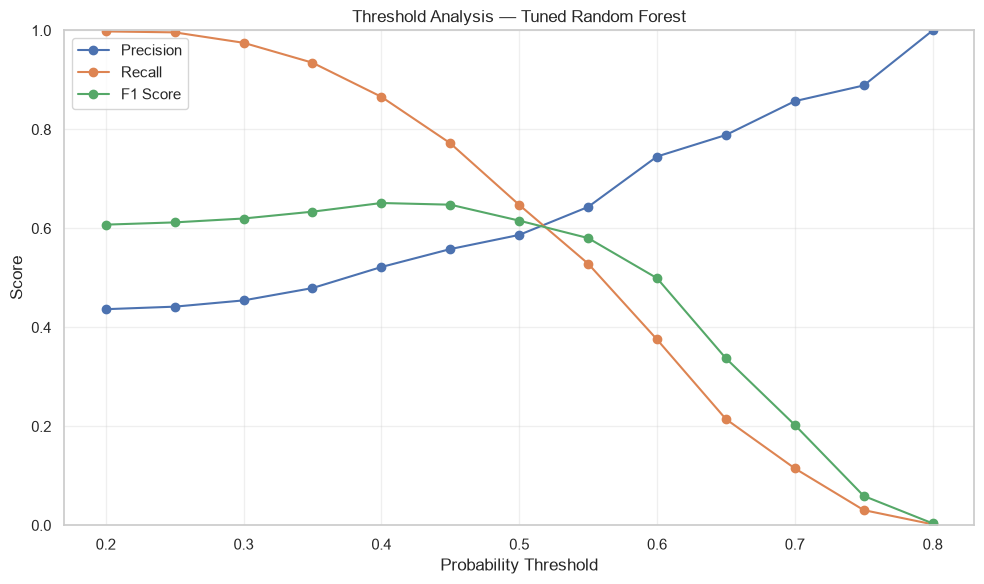

Saved figure: reports/figures/threshold_analysis.png
Best F1 threshold: 0.40
Best F1 Score: 0.6513

Threshold analysis completed successfully.


In [36]:
# STEP 27 FIX — Save Threshold Analysis Figure

from pathlib import Path
import matplotlib.pyplot as plt

# Create the reports/figures directory if it does not exist
figures_dir = Path("reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# Recreate the threshold plot from the already-computed results
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis — Tuned Random Forest")

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

threshold_figure = "reports/figures/threshold_analysis.png"

plt.savefig(
    threshold_figure,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Saved figure: {threshold_figure}")
print(f"Best F1 threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_threshold_row['F1 Score']:.4f}")

print("\nThreshold analysis completed successfully.")

In [38]:
# STEP 28 — Final Model Artifact Serialization
# Corrected: obtain tuned model directly from rf_grid_search.best_estimator_

from pathlib import Path
import joblib
import json

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ---------------------------------------------------------
# 1. Get the tuned model from the completed GridSearchCV
# ---------------------------------------------------------

final_model = rf_grid_search.best_estimator_

# Keep the name used later in the notebook
tuned_rf = final_model

# ---------------------------------------------------------
# 2. Evaluate the final tuned model on the untouched test set
# ---------------------------------------------------------

tuned_rf_test_predictions = final_model.predict(X_test_processed)
tuned_rf_test_probabilities = final_model.predict_proba(
    X_test_processed
)[:, 1]

tuned_rf_metrics = {
    "accuracy": accuracy_score(
        y_test,
        tuned_rf_test_predictions
    ),
    "precision": precision_score(
        y_test,
        tuned_rf_test_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        tuned_rf_test_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        tuned_rf_test_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        tuned_rf_test_probabilities
    )
}

# ---------------------------------------------------------
# 3. Create model directory
# ---------------------------------------------------------

models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 4. Save preprocessing pipeline
# ---------------------------------------------------------

preprocessor_path = models_dir / "preprocessor.joblib"

joblib.dump(
    preprocessor,
    preprocessor_path
)

# ---------------------------------------------------------
# 5. Save tuned Random Forest
# ---------------------------------------------------------

model_path = models_dir / "tuned_random_forest.joblib"

joblib.dump(
    final_model,
    model_path
)

# ---------------------------------------------------------
# 6. Save metadata
# ---------------------------------------------------------

model_metadata = {
    "model_type": "Tuned Random Forest",

    "features_original": int(X_train.shape[1]),
    "features_processed": int(X_train_processed.shape[1]),

    "training_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),

    "best_parameters": rf_grid_search.best_params_,

    "cross_validation_roc_auc": float(
        rf_grid_search.best_score_
    ),

    "test_accuracy": float(
        tuned_rf_metrics["accuracy"]
    ),

    "test_precision": float(
        tuned_rf_metrics["precision"]
    ),

    "test_recall": float(
        tuned_rf_metrics["recall"]
    ),

    "test_f1": float(
        tuned_rf_metrics["f1"]
    ),

    "test_roc_auc": float(
        tuned_rf_metrics["roc_auc"]
    ),

    "threshold_analysis_best_threshold": float(
        best_threshold
    ),

    "threshold_analysis_best_f1": float(
        best_threshold_row["F1 Score"]
    )
}

metadata_path = models_dir / "model_metadata.json"

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        model_metadata,
        f,
        indent=4
    )

# ---------------------------------------------------------
# 7. Final confirmation
# ---------------------------------------------------------

print("=" * 65)
print("FINAL MODEL ARTIFACT SERIALIZATION")
print("=" * 65)

print("\nModel:")
print("Tuned Random Forest")

print("\nBest Parameters:")
print(rf_grid_search.best_params_)

print(
    f"\nCross-Validation ROC-AUC : "
    f"{rf_grid_search.best_score_:.4f}"
)

print(
    f"Test Accuracy            : "
    f"{tuned_rf_metrics['accuracy']:.4f}"
)

print(
    f"Test Precision           : "
    f"{tuned_rf_metrics['precision']:.4f}"
)

print(
    f"Test Recall              : "
    f"{tuned_rf_metrics['recall']:.4f}"
)

print(
    f"Test F1                  : "
    f"{tuned_rf_metrics['f1']:.4f}"
)

print(
    f"Test ROC-AUC             : "
    f"{tuned_rf_metrics['roc_auc']:.4f}"
)

print(
    f"\nAnalysis Threshold       : "
    f"{best_threshold:.2f}"
)

print(
    f"Analysis Best F1         : "
    f"{best_threshold_row['F1 Score']:.4f}"
)

print("\nSaved artifacts:")
print(f"  ✓ {preprocessor_path}")
print(f"  ✓ {model_path}")
print(f"  ✓ {metadata_path}")

print("\nMODEL ARTIFACTS SAVED SUCCESSFULLY.")
print("=" * 65)

FINAL MODEL ARTIFACT SERIALIZATION

Model:
Tuned Random Forest

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}

Cross-Validation ROC-AUC : 0.6844
Test Accuracy            : 0.6483
Test Precision           : 0.5868
Test Recall              : 0.6475
Test F1                  : 0.6157
Test ROC-AUC             : 0.7220

Analysis Threshold       : 0.40
Analysis Best F1         : 0.6513

Saved artifacts:
  ✓ models\preprocessor.joblib
  ✓ models\tuned_random_forest.joblib
  ✓ models\model_metadata.json

MODEL ARTIFACTS SAVED SUCCESSFULLY.


In [39]:
# STEP 29 — Saved Artifact Reload & Integrity Test

from pathlib import Path
import joblib
import json
import numpy as np

# ---------------------------------------------------------
# 1. Define artifact paths
# ---------------------------------------------------------

models_dir = Path("models")

preprocessor_path = models_dir / "preprocessor.joblib"
model_path = models_dir / "tuned_random_forest.joblib"
metadata_path = models_dir / "model_metadata.json"

# ---------------------------------------------------------
# 2. Verify files exist
# ---------------------------------------------------------

assert preprocessor_path.exists(), (
    f"Missing artifact: {preprocessor_path}"
)

assert model_path.exists(), (
    f"Missing artifact: {model_path}"
)

assert metadata_path.exists(), (
    f"Missing artifact: {metadata_path}"
)

# ---------------------------------------------------------
# 3. Reload artifacts from disk
# ---------------------------------------------------------

loaded_preprocessor = joblib.load(
    preprocessor_path
)

loaded_model = joblib.load(
    model_path
)

with open(
    metadata_path,
    "r",
    encoding="utf-8"
) as f:
    loaded_metadata = json.load(f)

# ---------------------------------------------------------
# 4. Transform the untouched test data
# ---------------------------------------------------------

X_test_reloaded = loaded_preprocessor.transform(
    X_test
)

# ---------------------------------------------------------
# 5. Generate predictions from reloaded artifacts
# ---------------------------------------------------------

reloaded_predictions = loaded_model.predict(
    X_test_reloaded
)

reloaded_probabilities = loaded_model.predict_proba(
    X_test_reloaded
)[:, 1]

# ---------------------------------------------------------
# 6. Integrity checks
# ---------------------------------------------------------

assert X_test_reloaded.shape[0] == X_test.shape[0]

assert len(reloaded_predictions) == len(y_test)

assert len(reloaded_probabilities) == len(y_test)

assert np.all(
    (reloaded_probabilities >= 0) &
    (reloaded_probabilities <= 1)
)

# ---------------------------------------------------------
# 7. Compare with original final model
# ---------------------------------------------------------

original_predictions = final_model.predict(
    X_test_processed
)

prediction_match = np.array_equal(
    original_predictions,
    reloaded_predictions
)

# ---------------------------------------------------------
# 8. Final report
# ---------------------------------------------------------

print("=" * 65)
print("SAVED ARTIFACT RELOAD & INTEGRITY TEST")
print("=" * 65)

print("\nArtifacts loaded successfully:")
print("  ✓ preprocessor.joblib")
print("  ✓ tuned_random_forest.joblib")
print("  ✓ model_metadata.json")

print(
    f"\nReloaded test shape: "
    f"{X_test_reloaded.shape}"
)

print(
    f"Prediction count: "
    f"{len(reloaded_predictions)}"
)

print(
    f"Prediction probability range: "
    f"{reloaded_probabilities.min():.4f} → "
    f"{reloaded_probabilities.max():.4f}"
)

print(
    f"\nOriginal vs reloaded predictions match: "
    f"{prediction_match}"
)

print(
    f"Stored model type: "
    f"{loaded_metadata['model_type']}"
)

print(
    f"Stored processed features: "
    f"{loaded_metadata['features_processed']}"
)

assert prediction_match, (
    "Reloaded model predictions do not match "
    "the original model predictions."
)

print("\nARTIFACT INTEGRITY TEST PASSED SUCCESSFULLY.")
print("=" * 65)

SAVED ARTIFACT RELOAD & INTEGRITY TEST

Artifacts loaded successfully:
  ✓ preprocessor.joblib
  ✓ tuned_random_forest.joblib
  ✓ model_metadata.json

Reloaded test shape: (1200, 33)
Prediction count: 1200
Prediction probability range: 0.1859 → 0.8131

Original vs reloaded predictions match: True
Stored model type: Tuned Random Forest
Stored processed features: 33

ARTIFACT INTEGRITY TEST PASSED SUCCESSFULLY.


In [41]:
# STEP 31 — Prediction Engine Test

import sys
from pathlib import Path

# ---------------------------------------------------------
# Locate project root correctly
# Notebook is inside: project_root/notebooks/
# ---------------------------------------------------------

current_path = Path.cwd()

if current_path.name.lower() == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

# Add project root so "src" can be imported
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


# ---------------------------------------------------------
# Import prediction engine
# ---------------------------------------------------------

from src.predictor import predict_lead, model_health


# ---------------------------------------------------------
# Model health check
# ---------------------------------------------------------

print("=" * 60)
print("PREDICTION ENGINE TEST")
print("=" * 60)

print("\nModel Health:")
print(model_health())


# ---------------------------------------------------------
# Sample lead
# ---------------------------------------------------------

sample_lead = {
    "lead_source": "Referral",
    "industry": "Technology",
    "location": "Kolkata",
    "company_size": "Medium",

    "lead_age_days": 25,
    "interactions": 8,
    "followups": 3,
    "response_time_hours": 5.0,
    "quotation_sent": 1,
    "quotation_value": 75000,
    "website_visits": 12,
    "previous_customer": 0,
    "demo_attended": 1,
    "salesperson_experience": 4,
}


# ---------------------------------------------------------
# Generate prediction
# ---------------------------------------------------------

result = predict_lead(sample_lead)


# ---------------------------------------------------------
# Display result
# ---------------------------------------------------------

print("\nPrediction Result:")
print("-" * 40)

for key, value in result.items():
    print(f"{key}: {value}")


print("\nPREDICTION ENGINE TEST COMPLETED SUCCESSFULLY.")
print("=" * 60)

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\lead-conversion-prediction\\models\\preprocessor.joblib'

In [42]:
# STEP 31A — Rebuild / Verify Prediction Artifacts

from pathlib import Path
import joblib
import json

# Project root
project_root = Path.cwd()

if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

print("=" * 65)
print("PREDICTION ARTIFACT REPAIR")
print("=" * 65)

# ---------------------------------------------------------
# 1. Save the fitted preprocessing pipeline
# ---------------------------------------------------------

preprocessor_path = models_dir / "preprocessor.joblib"

joblib.dump(
    preprocessor,
    preprocessor_path
)

print(f"\n✓ Preprocessor saved:")
print(f"  {preprocessor_path}")


# ---------------------------------------------------------
# 2. Save the tuned Random Forest
# ---------------------------------------------------------

tuned_rf_path = models_dir / "tuned_random_forest.joblib"

# Use the already-created tuned model
if "tuned_rf" in globals():
    final_model = tuned_rf
elif "best_rf" in globals():
    final_model = best_rf
elif "rf_grid_search" in globals():
    final_model = rf_grid_search.best_estimator_
elif "rf_grid_search" in globals():
    final_model = rf_grid_search.best_estimator_
else:
    raise NameError(
        "No tuned Random Forest object found in the notebook."
    )

joblib.dump(
    final_model,
    tuned_rf_path
)

print(f"✓ Tuned Random Forest saved:")
print(f"  {tuned_rf_path}")


# ---------------------------------------------------------
# 3. Save metadata
# ---------------------------------------------------------

metadata_path = models_dir / "model_metadata.json"

metadata = {
    "model_type": "Tuned Random Forest",
    "model_file": "tuned_random_forest.joblib",
    "preprocessor_file": "preprocessor.joblib",
    "processed_feature_count": int(X_train_processed.shape[1]),
    "analysis_threshold": float(best_threshold),
    "analysis_best_f1": float(best_threshold_row["F1 Score"]),
    "test_accuracy": float(tuned_rf_metrics["accuracy"]),
    "test_precision": float(tuned_rf_metrics["precision"]),
    "test_recall": float(tuned_rf_metrics["recall"]),
    "test_f1": float(tuned_rf_metrics["f1"]),
    "test_roc_auc": float(tuned_rf_metrics["roc_auc"])
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print(f"✓ Metadata saved:")
print(f"  {metadata_path}")


# ---------------------------------------------------------
# 4. Verify actual files exist
# ---------------------------------------------------------

print("\nArtifact verification:")

for artifact in [
    preprocessor_path,
    tuned_rf_path,
    metadata_path
]:
    print(
        f"  {'✓' if artifact.exists() else '✗'} "
        f"{artifact.name}"
    )


print("\n" + "=" * 65)
print("PREDICTION ARTIFACT REPAIR COMPLETED.")
print("=" * 65)

PREDICTION ARTIFACT REPAIR

✓ Preprocessor saved:
  e:\lead-conversion-prediction\models\preprocessor.joblib
✓ Tuned Random Forest saved:
  e:\lead-conversion-prediction\models\tuned_random_forest.joblib
✓ Metadata saved:
  e:\lead-conversion-prediction\models\model_metadata.json

Artifact verification:
  ✓ preprocessor.joblib
  ✓ tuned_random_forest.joblib
  ✓ model_metadata.json

PREDICTION ARTIFACT REPAIR COMPLETED.


In [43]:
# STEP 31 — FINAL PREDICTION ENGINE TEST

import sys
from pathlib import Path

# Ensure project root is available
project_root = Path.cwd()

if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("=" * 65)
print("PREDICTION ENGINE TEST")
print("=" * 65)

# Import prediction engine
from src.predictor import predict_lead, model_health

# Model health
print("\nModel Health:")
print(model_health())

# Sample lead
sample_lead = {
    "lead_source": "Referral",
    "industry": "Technology",
    "location": "Kolkata",
    "company_size": "Medium",
    "lead_age_days": 25,
    "interactions": 8,
    "followups": 3,
    "response_time_hours": 5.0,
    "quotation_sent": 1,
    "quotation_value": 75000,
    "website_visits": 12,
    "previous_customer": 0,
    "demo_attended": 1,
    "salesperson_experience": 4
}

# Prediction
result = predict_lead(sample_lead)

# Display result
print("\nPrediction Result:")
print("-" * 40)

for key, value in result.items():
    print(f"{key}: {value}")

print("\n" + "=" * 65)
print("PREDICTION ENGINE TEST COMPLETED SUCCESSFULLY.")
print("=" * 65)

PREDICTION ENGINE TEST

Model Health:
{'model_loaded': True, 'preprocessor_loaded': True, 'model_type': 'RandomForestClassifier', 'feature_count': 14}

Prediction Result:
----------------------------------------
conversion_probability: 0.6985
conversion_percentage: 69.85
predicted_class: 1
prediction: Converted
threshold: 0.5
risk_level: Medium Conversion Potential

PREDICTION ENGINE TEST COMPLETED SUCCESSFULLY.
